# lappy Benchmark Suite — Overview

This notebook summarises results across all five parameter sweeps. Read this first for a high-level picture; the numbered notebooks (`01_`–`05_`) contain the full analysis of each sweep.

## What is benchmarked?

The `lappy` module computes Laplacian eigenvalues of planar domains using the **Method of Particular Solutions (MPS)** with a GSVD formulation. The benchmark suite investigates how solver accuracy and cost depend on five configuration axes:

| Notebook | Sweep | Variable(s) swept |
|---|---|---|
| `01_basis_size` | basis_size | Total basis size; FB/FS fraction |
| `02_fb_corner` | fb_corner | FB order allocation strategy at corners |
| `03_fs_placement` | fs_placement | FS source standoff distance; segment strategy |
| `04_regularization` | regularization | GSVD regularisation tolerance (rtol) |
| `05_n_eigs` | n_eigs | Number of eigenvalues requested |

## Default solver configuration

| Parameter | Default | Meaning |
|---|---|---|
| `n_fb` | varies | Fourier-Bessel (corner) basis functions |
| `n_fs` | varies | Fundamental-solution basis functions |
| `fb_strategy` | `singular_angle_weighted` | How FB orders are distributed across corners |
| `fs_d_strategy` | `inradius_fraction` | How FS source distance is set |
| `fs_d_scale` | 0.15 | Source distance as fraction of inradius |
| `fs_seg_strategy` | `length_weighted` | FS density proportional to segment length |
| `bdry_pts_factor` | 2.0 | Boundary points = factor × n_basis |
| `int_pts_factor` | 1.0 | Interior points = factor × n_basis |
| `rtol` | 1e-12 | GSVD regularisation tolerance |
| `ltol` | 1e-15 | Lifting tolerance |
| `ppl` | 10 | Points per level in eigenvalue search |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import nb_utils

nb_utils.set_publication_style()
RESULTS_DIR = os.path.abspath('../results')

# Load all sweeps
print('Loading sweeps...')
df_bs, raw_bs = nb_utils.load_sweep('basis_size', RESULTS_DIR)
df_fb, raw_fb = nb_utils.load_sweep('fb_corner', RESULTS_DIR)
df_fs, raw_fs = nb_utils.load_sweep('fs_placement', RESULTS_DIR)
df_reg, raw_reg = nb_utils.load_sweep('regularization', RESULTS_DIR)
df_ne, raw_ne = nb_utils.load_sweep('n_eigs', RESULTS_DIR)
print(f'Loaded: basis_size={len(df_bs)}, fb_corner={len(df_fb)}, '
      f'fs_placement={len(df_fs)}, regularization={len(df_reg)}, n_eigs={len(df_ne)}')

Loading sweeps...
Loaded: basis_size=205, fb_corner=16, fs_placement=47, regularization=16, n_eigs=60


## Best Accuracy Achieved (by domain)

The minimum `max_rel_error` observed across all configurations for each domain that has reference eigenvalues.

In [2]:
def best_error(df, domain):
    sub = df[(df['domain_name'] == domain) & df['max_rel_error'].notna()]
    return sub['max_rel_error'].min() if len(sub) > 0 else np.nan

all_ref_domains = sorted(
    nb_utils.DOMAINS_WITH_REFERENCE &
    set(df_bs['domain_name'].unique()) |
    set(df_reg['domain_name'].unique()) |
    set(df_ne['domain_name'].unique())
)

summary_rows = []
for dom in sorted(all_ref_domains):
    summary_rows.append({
        'Domain': nb_utils.label_domain(dom),
        'basis_size sweep': best_error(df_bs, dom),
        'regularization sweep': best_error(df_reg, dom),
        'n_eigs sweep': best_error(df_ne, dom),
    })

summary = pd.DataFrame(summary_rows).set_index('Domain')
summary.style.format('{:.2e}', na_rep='—').set_caption('Best max_rel_error achieved per domain')

,basis_size sweep,regularization sweep,n_eigs sweep
Domain,,,
GWW domain 1,1.09e-11,2.69e-11,1.55e-12
L-shape,5.01e-16,8.77e-16,7.79e-16
Disk sector,1.07e-05,—,—
Equilateral triangle,1.19e-15,—,—
Isosceles right triangle,1.69e-16,—,—
Rectangle (2×1),3.39e-16,2.88e-16,1.80e-16


## Convergence Overview

How does accuracy improve with basis size (balanced FB/FS mix) across all benchmark domains?

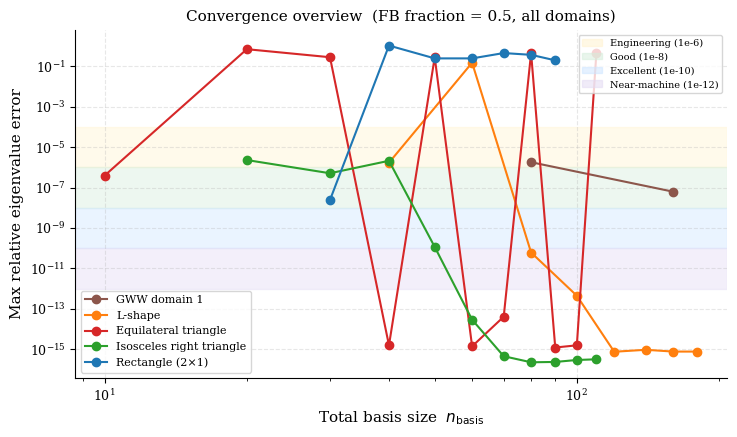

In [3]:
domains_bs = sorted(df_bs['domain_name'].unique())
colors = nb_utils.domain_color_map(domains_bs)
sub = df_bs[df_bs['fb_fraction'].round(3) == 0.5]

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Accuracy bands
bands = [(1e-6, 1e-4, '#fff3cd', 'Engineering (1e-6)'),
         (1e-8, 1e-6, '#d4edda', 'Good (1e-8)'),
         (1e-10, 1e-8, '#cce5ff', 'Excellent (1e-10)'),
         (1e-12, 1e-10, '#e2d9f3', 'Near-machine (1e-12)')]
for lo, hi, color, _ in bands:
    ax.axhspan(lo, hi, color=color, alpha=0.4, zorder=0)

for dom in domains_bs:
    d = sub[sub['domain_name'] == dom].sort_values('n_basis')
    if d['max_rel_error'].notna().any():
        ax.loglog(d['n_basis'], d['max_rel_error'],
                  marker='o', color=colors[dom],
                  label=nb_utils.label_domain(dom))

# Band legend
band_patches = [mpatches.Patch(color=c, alpha=0.5, label=lbl)
                for _, _, c, lbl in bands]
l1 = ax.legend(fontsize=8, loc='lower left')
ax.add_artist(l1)
ax.legend(handles=band_patches, fontsize=7, loc='upper right')

ax.set_xlabel('Total basis size  $n_{\\mathrm{basis}}$')
ax.set_ylabel('Max relative eigenvalue error')
ax.set_title('Convergence overview  (FB fraction = 0.5, all domains)')
plt.tight_layout()
plt.show()

## Strategy Rankings (FB Corner Sweep)

Which Fourier-Bessel order allocation strategy achieves the lowest error?

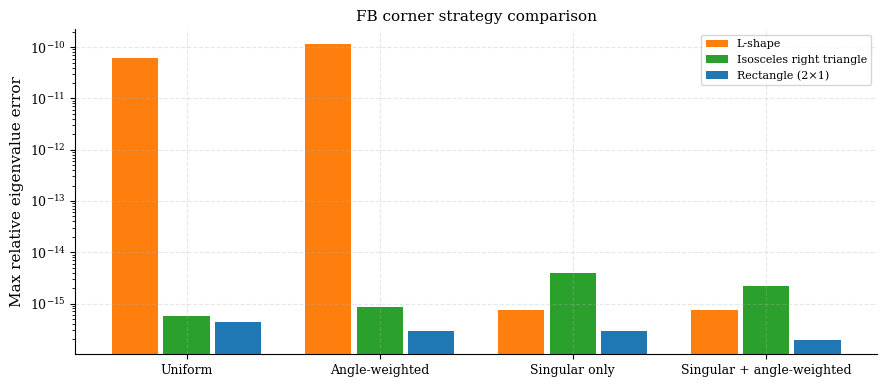

In [4]:
ref_domains_fb = [d for d in df_fb['domain_name'].unique()
                  if d in nb_utils.DOMAINS_WITH_REFERENCE]
strategies = nb_utils.STRATEGY_ORDER
x = np.arange(len(strategies))
width = 0.8 / len(ref_domains_fb)
fb_colors = nb_utils.domain_color_map(df_fb['domain_name'].unique())

fig, ax = plt.subplots(figsize=(9, 4))
for i, dom in enumerate(ref_domains_fb):
    vals = []
    for strat in strategies:
        row = df_fb[(df_fb['domain_name'] == dom) & (df_fb['fb_strategy'] == strat)]
        vals.append(row['max_rel_error'].values[0]
                    if len(row) > 0 and row['max_rel_error'].notna().any() else np.nan)
    offset = (i - len(ref_domains_fb) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width=width * 0.9,
           color=fb_colors[dom], label=nb_utils.label_domain(dom))

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([nb_utils.label_strategy(s) for s in strategies], fontsize=9)
ax.set_ylabel('Max relative eigenvalue error')
ax.set_title('FB corner strategy comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Regularization Sweet Spot

The default `rtol = 1e-12` (dashed line) is marked. The expected U-curve reflects the trade-off between over- and under-regularisation.

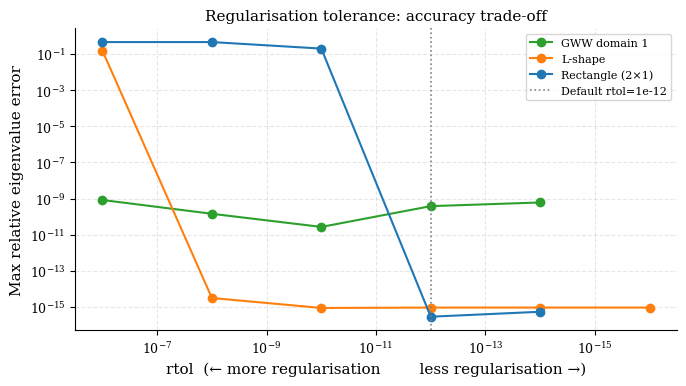

In [5]:
domains_reg = sorted(df_reg['domain_name'].unique())
reg_colors = nb_utils.domain_color_map(domains_reg)

fig, ax = plt.subplots(figsize=(7, 4))
for dom in domains_reg:
    d = df_reg[df_reg['domain_name'] == dom].sort_values('rtol')
    ax.loglog(d['rtol'], d['max_rel_error'],
              marker='o', color=reg_colors[dom],
              label=nb_utils.label_domain(dom))

nb_utils.annotate_default_rtol(ax, 1e-12)
ax.invert_xaxis()
ax.set_xlabel('rtol  (← more regularisation        less regularisation →)')
ax.set_ylabel('Max relative eigenvalue error')
ax.set_title('Regularisation tolerance: accuracy trade-off')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Accuracy vs Computational Cost

The Pareto frontier across basis_size and n_eigs sweeps. Point size encodes `n_basis`.

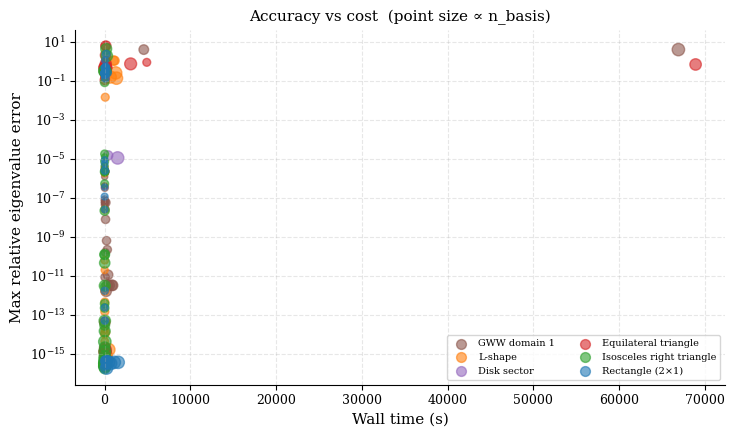

In [6]:
combined = pd.concat([df_bs, df_ne], ignore_index=True)
combined = combined[combined['max_rel_error'].notna()]
all_doms = sorted(combined['domain_name'].unique())
comb_colors = nb_utils.domain_color_map(all_doms)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for dom in all_doms:
    d = combined[combined['domain_name'] == dom]
    nb_min, nb_max = d['n_basis'].min(), d['n_basis'].max()
    sizes = 20 + 60 * (d['n_basis'] - nb_min) / max(nb_max - nb_min, 1)
    ax.scatter(d['wall_time'], d['max_rel_error'],
               s=sizes, color=comb_colors[dom], alpha=0.6,
               label=nb_utils.label_domain(dom))

ax.set_yscale('log')
ax.set_xlabel('Wall time (s)')
ax.set_ylabel('Max relative eigenvalue error')
ax.set_title('Accuracy vs cost  (point size ∝ n_basis)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Recommendations

Based on the benchmark results, the following guidelines are recommended for practical use of `lappy`:

**Basis size:**
- Use `n_basis ≥ 160` for `max_rel_error < 1e-8` on typical polygon domains.
- A balanced 50% FB / 50% FS mix is a safe default; some domains favour pure FS (smooth boundaries) or pure FB (many corners).

**FB corner strategy:**
- Use `singular_angle_weighted` for domains with re-entrant or irrational-angle corners (L-shape, etc.).
- For convex polygons with only rational angles, all strategies perform similarly.

**FS source placement:**
- `fs_d_scale = 0.15` (default) is near-optimal for most domains.
- `length_weighted` segment distribution is marginally better than `uniform` for non-uniform boundaries.

**Regularization:**
- The default `rtol = 1e-12` sits in the robust plateau for all tested domains.
- Values outside the range [1e-14, 1e-10] risk either truncating the basis or admitting noise.

**Scaling with k:**
- Required basis size grows approximately linearly with k (number of eigenvalues).
- As a rule of thumb: `n_basis ≈ 10–15 × k` for `max_rel_error < 1e-8`.